In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from itertools import combinations

# 한글 폰트
_candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic", "Noto Sans CJK KR"]
_available  = {f.name for f in fm.fontManager.ttflist}
_font       = next((f for f in _candidates if f in _available), None)
if _font:
    plt.rcParams["font.family"] = _font
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100

# DOE 데이터셋 생성 (미니탭용)
원본 → 20분 리샘플 → SI 계산 → 3H Lag 정렬 → doe_dataset.csv 저장

In [2]:
# ── Steps 1~4: lag.ipynb와 동일 ──────────────────────────────────────────────

# Step 1. 원본 로드
df_raw = pd.read_csv(
    "MiningProcess_Flotation_Plant_Database.csv",
    decimal=",", thousands="."
)
df_raw["date"] = pd.to_datetime(df_raw["date"])
df_raw = df_raw.sort_values("date").reset_index(drop=True)

# Step 2. 타임스탬프 복원 (같은 시간대 행 순서 × 20초)
df_raw["_seq"]      = df_raw.groupby("date").cumcount()
df_raw["date_fine"] = df_raw["date"] + pd.to_timedelta(df_raw["_seq"] * 20, unit="s")
df_raw = df_raw.drop(columns=["date", "_seq"]).set_index("date_fine")
df_raw.index.name = "date"

# Step 3. 20분 리샘플 + 공백 구간 NaN 보존
df_20m = df_raw.resample("20min").mean().asfreq("20min")

# Step 4. SI 계산 (Rm, Jg 클리핑 → SI → 윈저라이징)
Feed_Fe = df_20m["% Iron Feed"]
Conc_Fe = df_20m["% Iron Concentrate"]
Feed_Si = df_20m["% Silica Feed"]
Conc_Si = df_20m["% Silica Concentrate"]

Y            = (Feed_Fe - 15.0) / (Conc_Fe - 15.0).replace(0, np.nan)
df_20m["Rm"] = (Y * (Conc_Fe / Feed_Fe) * 100).clip(0, 100)
df_20m["Jg"] = ((1 - Y * (Conc_Si / Feed_Si)) * 100).clip(0, 100)

si_inner     = (df_20m["Rm"] * df_20m["Jg"] /
                ((100.1 - df_20m["Rm"]) * (100.1 - df_20m["Jg"]))).clip(lower=0)
si_raw       = np.sqrt(si_inner)
si_99        = si_raw.quantile(0.99)
df_20m["SI"] = si_raw.clip(upper=si_99)

print(f"df_20m 준비 완료: {len(df_20m):,}행 × {df_20m.shape[1]}컬럼")
print(f"유효 SI 행: {df_20m['SI'].notna().sum():,}")
df_20m.head(9)

df_20m 준비 완료: 13,245행 × 26컬럼
유효 SI 행: 12,291


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate,Rm,Jg,SI
date,,,,,,,,,,,,,,,,,,,,,
2017-03-10 01:00:00,55.2,16.98,2938.926075,581.248383,397.369983,10.121225,1.722499,250.462133,250.004333,250.090317,...,451.181800,448.688100,453.905683,469.382450,445.126750,66.91,1.31,93.870034,94.025403,15.271599
2017-03-10 01:20:00,55.2,16.98,3430.846833,564.795883,399.646183,10.103617,1.723635,251.526000,250.644233,250.448883,...,449.635367,449.203333,448.870583,461.717867,450.121067,66.91,1.31,93.870034,94.025403,15.271599
2017-03-10 01:40:00,55.2,16.98,3113.155185,591.596778,399.298444,10.115857,1.743983,251.550241,250.007870,249.975370,...,450.621056,452.060130,465.578889,461.790315,456.996833,66.91,1.31,93.870034,94.025403,15.271599
2017-03-10 02:00:00,55.2,16.98,3373.192667,552.668550,400.123450,10.094875,1.687015,250.538067,249.996750,250.003767,...,451.058100,451.171000,455.568450,454.012850,455.502383,67.06,1.11,93.809401,94.952141,16.585029
2017-03-10 02:20:00,55.2,16.98,2980.648083,538.419100,399.442150,10.121930,1.668600,249.331400,249.750700,249.990233,...,448.989883,450.956117,440.500650,453.394250,446.950367,67.06,1.11,93.809401,94.952141,16.585029
2017-03-10 02:40:00,55.2,16.98,3045.928417,520.571333,400.049867,10.172420,1.647738,249.772300,250.894700,250.105950,...,450.195683,448.859300,450.099850,459.097483,451.710350,67.06,1.11,93.809401,94.952141,16.585029
2017-03-10 03:00:00,55.2,16.98,3377.862667,597.242533,396.742700,10.012403,1.745132,249.978533,250.148900,250.187617,...,452.108333,452.950083,452.553600,465.241050,446.444300,66.97,1.27,93.845739,94.214520,15.498414
2017-03-10 03:20:00,55.2,16.98,3522.168500,590.005883,399.648883,10.037700,1.728198,250.551667,249.984233,249.872683,...,450.522033,451.403000,452.407750,460.749967,454.883867,66.97,1.27,93.845739,94.214520,15.498414
2017-03-10 03:40:00,55.2,16.98,3538.417667,588.471817,399.899833,10.095107,1.724802,249.953783,250.179367,250.078750,...,450.075100,449.084383,448.441217,453.952917,449.562000,66.97,1.27,93.845739,94.214520,15.498414


In [3]:
LAG_STEPS = 9   # 9스텝 × 20분 = 180분 = 3H

# X 변수 컬럼 (SI 계산용 중간변수 Rm, Jg 제외, 결과 변수도 제외)
X_COLS = [
    "% Iron Feed", "% Silica Feed",
    "Starch Flow", "Amina Flow", "Ore Pulp Flow", "Ore Pulp pH", "Ore Pulp Density",
    "Flotation Column 01 Air Flow", "Flotation Column 02 Air Flow",
    "Flotation Column 03 Air Flow", "Flotation Column 04 Air Flow",
    "Flotation Column 05 Air Flow", "Flotation Column 06 Air Flow",
    "Flotation Column 07 Air Flow",
    "Flotation Column 01 Level", "Flotation Column 02 Level",
    "Flotation Column 03 Level", "Flotation Column 04 Level",
    "Flotation Column 05 Level", "Flotation Column 06 Level",
    "Flotation Column 07 Level",
]

# Lag 정렬: SI를 9스텝 앞으로 당기기
df_lag = df_20m[X_COLS].copy()
df_lag["SI_3H"]  = df_20m["SI"].shift(-LAG_STEPS)  # 타겟: 3시간 후 SI
df_lag["SI_lag1"] = df_20m["SI"].shift(1)           # 피처: 20분 전 SI
df_lag["SI_lag2"] = df_20m["SI"].shift(2)           # 피처: 40분 전 SI

print(f"Lag 정렬 후 전체 행: {len(df_lag):,}")
print(f"  - 유효 쌍 (X & SI_3H 모두 존재): {df_lag.dropna().shape[0]:,}")
print(f"  - NaN 발생 (끝 {LAG_STEPS}행 + 공백 구간): {df_lag["SI_3H"].isna().sum():,}")


Lag 정렬 후 전체 행: 13,245
  - 유효 쌍 (X & SI_3H 모두 존재): 12,269
  - NaN 발생 (끝 9행 + 공백 구간): 963


In [4]:
# 과도 구간 제거 없이 NaN만 제거
df_clean = df_lag.dropna()

print("=== 데이터셋 요약 ===")
print(f"  원본 20분 행수     : {len(df_lag):,}")
print(f"  NaN 제거           : -{len(df_lag) - len(df_clean):,}")
print(f"  최종 유효 행수     : {len(df_clean):,}  ({len(df_clean)/len(df_lag)*100:.1f}% 보존)")
print(f"  컬럼 수            : {df_clean.shape[1]}  (X 21개 + SI_3H 1개)")
print()
print("=== SI_3H 기초 통계 ===")
display(df_clean["SI_3H"].describe().round(4))

# CSV 저장
output_path = "doe_dataset.csv"
df_clean.to_csv(output_path, encoding="utf-8-sig")
print(f"\n저장 완료: {output_path}")
display(df_clean.head(9))

=== 데이터셋 요약 ===
  원본 20분 행수     : 13,245
  NaN 제거           : -976
  최종 유효 행수     : 12,269  (92.6% 보존)
  컬럼 수            : 24  (X 21개 + SI_3H 1개)

=== SI_3H 기초 통계 ===


count    12269.0000
mean        13.6263
std          4.9569
min          0.0000
25%         10.2531
50%         12.6632
75%         15.6381
max         32.9454
Name: SI_3H, dtype: float64


저장 완료: doe_dataset.csv


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,SI_3H,SI_lag1,SI_lag2
date,,,,,,,,,,,,,,,,,,,,,
2017-03-10 01:40:00,55.2,16.98,3113.155185,591.596778,399.298444,10.115857,1.743983,251.550241,250.007870,249.975370,...,452.427778,444.827463,450.621056,452.060130,465.578889,461.790315,456.996833,15.034222,15.271599,15.271599
2017-03-10 02:00:00,55.2,16.98,3373.192667,552.668550,400.123450,10.094875,1.687015,250.538067,249.996750,250.003767,...,448.581567,449.727283,451.058100,451.171000,455.568450,454.012850,455.502383,15.197703,15.271599,15.271599
2017-03-10 02:20:00,55.2,16.98,2980.648083,538.419100,399.442150,10.121930,1.668600,249.331400,249.750700,249.990233,...,450.240500,459.578067,448.989883,450.956117,440.500650,453.394250,446.950367,15.197703,16.585029,15.271599
2017-03-10 02:40:00,55.2,16.98,3045.928417,520.571333,400.049867,10.172420,1.647738,249.772300,250.894700,250.105950,...,449.298017,441.442717,450.195683,448.859300,450.099850,459.097483,451.710350,15.197703,16.585029,16.585029
2017-03-10 03:00:00,55.2,16.98,3377.862667,597.242533,396.742700,10.012403,1.745132,249.978533,250.148900,250.187617,...,448.634317,453.230117,452.108333,452.950083,452.553600,465.241050,446.444300,16.368152,16.585029,16.585029
2017-03-10 03:20:00,55.2,16.98,3522.168500,590.005883,399.648883,10.037700,1.728198,250.551667,249.984233,249.872683,...,449.578333,449.661850,450.522033,451.403000,452.407750,460.749967,454.883867,16.368152,15.498414,16.585029
2017-03-10 03:40:00,55.2,16.98,3538.417667,588.471817,399.899833,10.095107,1.724802,249.953783,250.179367,250.078750,...,451.705983,449.714167,450.075100,449.084383,448.441217,453.952917,449.562000,16.368152,15.498414,15.498414
2017-03-10 04:00:00,55.2,16.98,3392.115333,601.877850,401.086233,9.903775,1.740084,249.889217,249.656517,250.193883,...,516.365300,519.494650,516.043283,535.825433,546.014200,547.577683,537.450917,10.524729,15.498414,15.498414
2017-03-10 04:20:00,55.2,16.98,3033.173974,593.560567,398.066217,9.909213,1.731588,250.568283,250.820167,249.824633,...,495.010417,499.201450,493.625750,497.223950,496.766050,503.339433,493.534000,10.524729,15.034222,15.498414


## Step 5. SI 분포 확인 + log 변환 미리보기

- 원본 왜도: **1.45** → 오른쪽 치우침
- log 변환 후 왜도: **0.45** → 정규분포에 근사
- SI = 0인 15개 행은 log 변환 전 제외

> **처리 순서: BE → VIF → log 변환**
> - 변수 선택(Step 6 OLS/BE, Step 8 VIF)은 **원본 SI_3H** 기준으로 수행
> - log 변환은 변수 선택 완료 후 Step 9(RSM)부터 적용
> - 이전 프로젝트 경험: log → BE/VIF 순서 시 성능 악화 확인

유효 행 수 (SI>0): 12,254  (제거: 15행)
원본 왜도: 1.4891  → 오른쪽 치우침
→ BE/VIF(Step 6~8)은 원본 SI_3H 기준으로 수행, log 변환은 Step 8 이후 적용


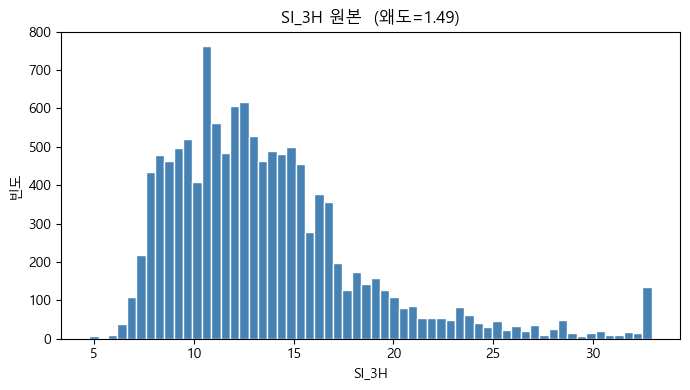

저장: si_distribution.png


In [5]:
# ── Step 5. SI 분포 확인 ──────────────────────────────────────────────────────
X_LABELS  = [f"X{str(i+1).zfill(2)}" for i in range(len(X_COLS))]
PROTECTED = ["X01", "X02"]  # 입력값, 제거 금지

# 0값 제거 (log 변환 대비)
df = df_clean[df_clean["SI_3H"] > 0].copy()

print(f"유효 행 수 (SI>0): {len(df):,}  (제거: {len(df_clean)-len(df)}행)")
print(f"원본 왜도: {df['SI_3H'].skew():.4f}  → 오른쪽 치우침")
print("→ BE/VIF(Step 6~8)은 원본 SI_3H 기준으로 수행, log 변환은 Step 8 이후 적용")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["SI_3H"], bins=60, color="steelblue", edgecolor="white", lw=0.4)
ax.set_title(f"SI_3H 원본  (왜도={df['SI_3H'].skew():.2f})")
ax.set_xlabel("SI_3H"); ax.set_ylabel("빈도")
plt.tight_layout()
plt.savefig("si_distribution.png", bbox_inches="tight")
plt.show()
print("저장: si_distribution.png")

## Step 6. OLS 회귀 — p-value 기반 유의 변수 선별

- X 표준화(StandardScaler) 후 OLS 회귀
- **p < 0.05** → 유의미한 변수
- 타겟: **SI_3H 원본** (변수 선택 단계 — log 변환 적용 전)

In [6]:
# ── Step 6. OLS 회귀 (타겟: 원본 SI_3H) ─────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[X_COLS])
X_sm     = sm.add_constant(
    pd.DataFrame(X_scaled, columns=X_LABELS, index=df.index)
)

y_raw = df["SI_3H"]   # 변수 선택은 원본 스케일 기준
ols   = sm.OLS(y_raw, X_sm).fit()

result = pd.DataFrame({
    "Name"   : X_COLS,
    "coef"   : ols.params[X_LABELS].values,
    "p-value": ols.pvalues[X_LABELS].values,
}, index=X_LABELS)
result["유의(p<0.05)"] = result["p-value"] < 0.05

print(f"=== OLS 결과 | R² = {ols.rsquared:.4f} | 타겟: SI_3H (원본) ===")
display(result.sort_values("p-value").round(4))

sig_vars   = result[result["유의(p<0.05)"]].index.tolist()
insig_vars = result[~result["유의(p<0.05)"]].index.tolist()
print(f"\n유의 변수 ({len(sig_vars)}개): {sig_vars}")
print(f"비유의 변수 ({len(insig_vars)}개): {insig_vars}")

=== OLS 결과 | R² = 0.4476 | 타겟: SI_3H (원본) ===


,Name,coef,p-value,유의(p<0.05)
X01,% Iron Feed,9.8885,0.0000,True
X02,% Silica Feed,7.8483,0.0000,True
X06,Ore Pulp pH,0.4082,0.0000,True
X07,Ore Pulp Density,-0.4947,0.0000,True
X08,Flotation Column 01 Air Flow,1.0010,0.0000,True
X13,Flotation Column 06 Air Flow,-0.5096,0.0000,True
X20,Flotation Column 06 Level,-0.2718,0.0000,True
X18,Flotation Column 04 Level,0.2614,0.0000,True
X03,Starch Flow,0.1742,0.0000,True
X15,Flotation Column 01 Level,0.2098,0.0013,True



유의 변수 (12개): ['X01', 'X02', 'X03', 'X06', 'X07', 'X08', 'X13', 'X14', 'X15', 'X16', 'X18', 'X20']
비유의 변수 (9개): ['X04', 'X05', 'X09', 'X10', 'X11', 'X12', 'X17', 'X19', 'X21']


## Step 7. 주효과도 (Main Effects Plot)

- 각 변수를 **5분위** 로 나눠 구간별 SI_3H 평균 시각화 (원본 기준)
- 노란 배경 = p < 0.05 유의 변수
- 파란 테두리 = X01·X02 (입력값)

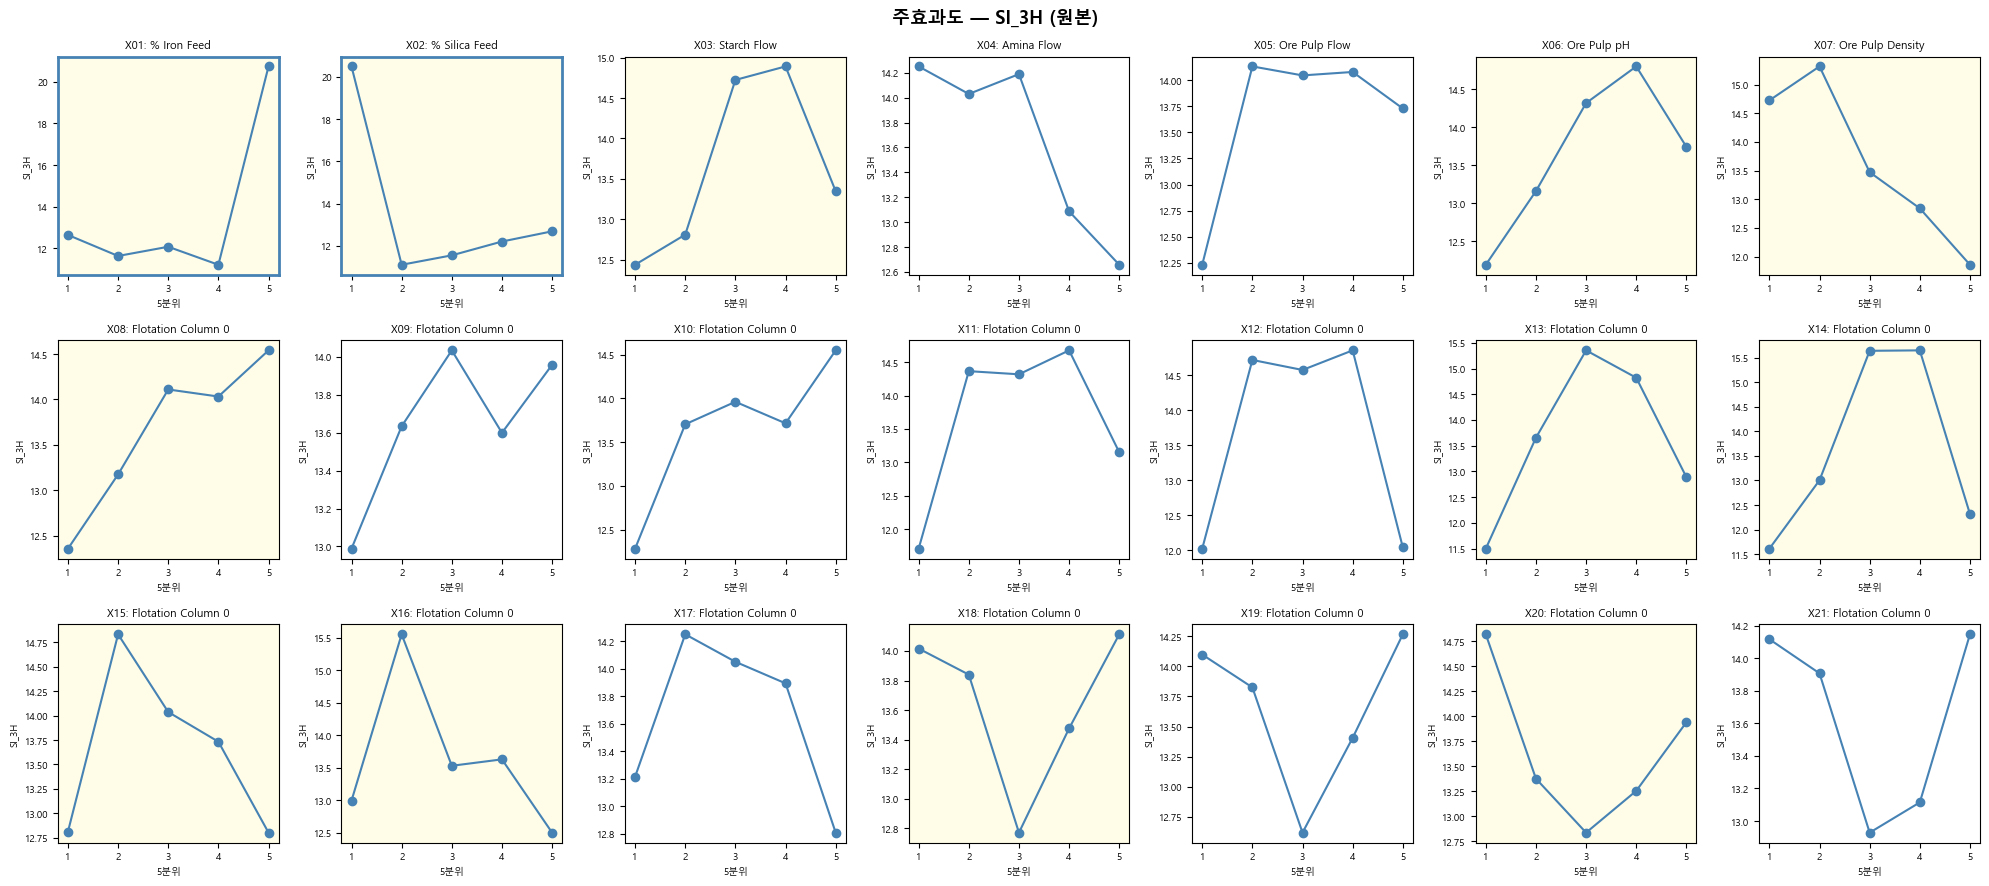

저장: main_effects_SI.png


In [7]:
# ── Step 7. 주효과도 (타겟: 원본 SI_3H) ─────────────────────────────────────
N_QUANTILE = 5
ncols = 7
nrows = (len(X_COLS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3))
fig.suptitle("주효과도 — SI_3H (원본)", fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, (col, lbl) in enumerate(zip(X_COLS, X_LABELS)):
    ax    = axes[i]
    q_bin = pd.qcut(df[col], N_QUANTILE, labels=False, duplicates="drop")
    means = df.groupby(q_bin)["SI_3H"].mean()
    if lbl in sig_vars:
        ax.set_facecolor("#fffde7")
    if lbl in PROTECTED:
        for spine in ax.spines.values():
            spine.set_edgecolor("steelblue"); spine.set_linewidth(2)
    ax.plot(means.index + 1, means.values, marker="o", color="steelblue", lw=1.5)
    ax.set_title(f"{lbl}: {col[:18]}", fontsize=8)
    ax.set_xlabel("5분위", fontsize=7)
    ax.set_ylabel("SI_3H", fontsize=7)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig("main_effects_SI.png", bbox_inches="tight")
plt.show()
print("저장: main_effects_SI.png")

## Step 8. VIF — 다중공선성 확인

| VIF | 해석 |
|-----|------|
| 1~5 | 양호 |
| 5~10 | 주의 |
| >10 | 제거 고려 |

> X01, X02는 VIF가 높아도 제거하지 않습니다.

In [8]:
# ── Step 8. VIF ─────────────────────────────────────────────────────────────
X_vif_df = pd.DataFrame(
    scaler.fit_transform(df[X_COLS]),
    columns=X_LABELS, index=df.index
)
vif_df = pd.DataFrame({
    "Var" : X_LABELS,
    "Name": X_COLS,
    "VIF" : [variance_inflation_factor(X_vif_df.values, i) for i in range(len(X_LABELS))],
}).sort_values('VIF', ascending=False).reset_index(drop=True)
vif_df["보호"] = vif_df["Var"].isin(PROTECTED)
print("=== VIF 결과 ===")
display(vif_df.round(2))

=== VIF 결과 ===


,Var,Name,VIF,보호
0,X01,% Iron Feed,19.60,True
1,X02,% Silica Feed,19.24,True
2,X10,Flotation Column 03 Air Flow,15.83,False
3,X08,Flotation Column 01 Air Flow,13.67,False
4,X14,Flotation Column 07 Air Flow,7.36,False
5,X13,Flotation Column 06 Air Flow,6.99,False
6,X09,Flotation Column 02 Air Flow,5.04,False
7,X19,Flotation Column 05 Level,4.15,False
8,X21,Flotation Column 07 Level,4.03,False
9,X15,Flotation Column 01 Level,3.85,False


---
## Step 8 완료 → log 변환 적용

BE(Step 6) + VIF(Step 8) 기반 변수 선택 완료.  
Step 9(RSM)부터는 `log(SI_3H)` 를 종속변수로 사용합니다.

| 단계 | 타겟 | 목적 |
|------|------|------|
| Step 6 OLS/BE | SI_3H 원본 | 원본 스케일에서 p-value 기반 변수 선택 |
| Step 8 VIF | SI_3H 원본 | 다중공선성 진단 (스케일 무관) |
| **Step 9~ RSM/XGBoost** | **log(SI_3H)** | **정규성 확보 후 최종 모델 적합** |

원본 왜도    : 1.4891
log 변환 왜도: 0.4474  → 정규분포에 근사


c:\Users\USER\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\USER\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


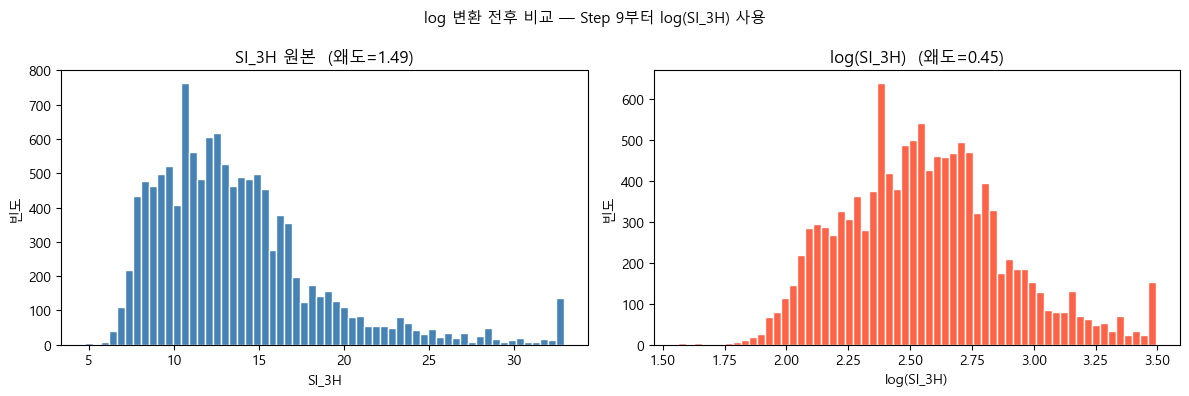

저장: si_log_transform.png


In [9]:
# ── BE/VIF 완료 후 log 변환 적용 ─────────────────────────────────────────────
df["log_SI"]      = np.log(df["SI_3H"])
df["log_SI_lag1"] = np.log(df["SI_lag1"])  # 20분 전 log(SI)
df["log_SI_lag2"] = np.log(df["SI_lag2"])  # 40분 전 log(SI)

print(f"원본 왜도    : {df['SI_3H'].skew():.4f}")
print(f"log 변환 왜도: {df['log_SI'].skew():.4f}  → 정규분포에 근사")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["SI_3H"],  bins=60, color="steelblue", edgecolor="white", lw=0.4)
axes[0].set_title(f"SI_3H 원본  (왜도={df['SI_3H'].skew():.2f})")
axes[0].set_xlabel("SI_3H"); axes[0].set_ylabel("빈도")
axes[1].hist(df["log_SI"], bins=60, color="tomato", edgecolor="white", lw=0.4)
axes[1].set_title(f"log(SI_3H)  (왜도={df['log_SI'].skew():.2f})")
axes[1].set_xlabel("log(SI_3H)"); axes[1].set_ylabel("빈도")
plt.suptitle("log 변환 전후 비교 — Step 9부터 log(SI_3H) 사용", fontsize=11)
plt.tight_layout()
plt.savefig("si_log_transform.png", bbox_inches="tight")
plt.show()
print("저장: si_log_transform.png")


## Step 9. RSM 집계 변수 + Backward Elimination

14개 개별 컬럼 → 4개 집계 변수로 압축:

| 변수 | 정의 |
|------|------|
| RA | Rougher Air (Col01~03 평균) |
| CA | Cleaner Air (Col04~07 평균) |
| RL | Rougher Level (Col01~03 평균) |
| CL | Cleaner Level (Col04~07 평균) |

> **P07(Ore Pulp Density)** 는 도메인 지식 기반 보호 변수로 강제 포함

In [10]:
# ── Step 9-1. 집계 변수 생성 ────────────────────────────────────────────────
AIR_COLS   = [c for c in X_COLS if 'Air Flow' in c]
LEVEL_COLS = [c for c in X_COLS if 'Level' in c]

df_rsm = pd.DataFrame(index=df.index)
PROCESS_LABELS = ["P01","P02","P03","P04","P05","P06","P07"]
for col, lbl in zip(X_COLS[:7], PROCESS_LABELS):
    df_rsm[lbl] = df[col]

df_rsm['RA'] = df[AIR_COLS[:3]].mean(axis=1)
df_rsm['CA'] = df[AIR_COLS[3:]].mean(axis=1)
df_rsm['RL'] = df[LEVEL_COLS[:3]].mean(axis=1)
df_rsm['CL'] = df[LEVEL_COLS[3:]].mean(axis=1)

VAR_LABELS = list(df_rsm.columns)  # 11개
VAR_NAMES  = {
    "P01": "% Iron Feed",       "P02": "% Silica Feed",
    "P03": "Starch Flow",       "P04": "Amina Flow",
    "P05": "Ore Pulp Flow",     "P06": "Ore Pulp pH",
    "P07": "Ore Pulp Density",
    "RA" : "Rougher Air (Col01~03)",   "CA": "Cleaner Air (Col04~07)",
    "RL" : "Rougher Level (Col01~03)", "CL": "Cleaner Level (Col04~07)",
}
PROTECTED_RSM = ["P01", "P02", "P07"]  # Ore Pulp Density 강제 포함
CAUSAL_PAIRS  = {('RA', 'RL'), ('CA', 'CL')}

print("=== RSM 입력 변수 ===")
for lbl in VAR_LABELS:
    tag = "  ← 보호 변수" if lbl in PROTECTED_RSM else ""
    print(f"  {lbl:4s}: {VAR_NAMES[lbl]}{tag}")

=== RSM 입력 변수 ===
  P01 : % Iron Feed  ← 보호 변수
  P02 : % Silica Feed  ← 보호 변수
  P03 : Starch Flow
  P04 : Amina Flow
  P05 : Ore Pulp Flow
  P06 : Ore Pulp pH
  P07 : Ore Pulp Density  ← 보호 변수
  RA  : Rougher Air (Col01~03)
  CA  : Cleaner Air (Col04~07)
  RL  : Rougher Level (Col01~03)
  CL  : Cleaner Level (Col04~07)


In [11]:
# ── Step 9-2. RSM 항 생성 + Backward Elimination ──────────────────────────
scaler_rsm   = StandardScaler()
X_rsm_scaled = scaler_rsm.fit_transform(df_rsm)
X_rsm_df     = pd.DataFrame(X_rsm_scaled, columns=VAR_LABELS, index=df.index)

rsm_terms = {}
for lbl in VAR_LABELS:
    rsm_terms[lbl] = X_rsm_df[lbl]
for lbl in VAR_LABELS:
    rsm_terms[f'{lbl}^2'] = X_rsm_df[lbl] ** 2
for a, b in combinations(VAR_LABELS, 2):
    if (a, b) not in CAUSAL_PAIRS and (b, a) not in CAUSAL_PAIRS:
        rsm_terms[f'{a}x{b}'] = X_rsm_df[a] * X_rsm_df[b]

X_rsm_full = sm.add_constant(pd.DataFrame(rsm_terms, index=df.index))
print(f"RSM 항 수: {X_rsm_full.shape[1]-1}개 (절편 제외)")

def term_to_name(term):
    if '^2' in term:
        lbl = term[:-2]
        return f'{VAR_NAMES.get(lbl, lbl)}²'
    elif 'x' in term:
        a, b = term.split('x', 1)
        return f'{VAR_NAMES.get(a,a)} × {VAR_NAMES.get(b,b)}'
    return VAR_NAMES.get(term, term)

y_rsm         = df["log_SI"]
current_terms = list(X_rsm_full.columns)
keep_terms    = set(['const'] + PROTECTED_RSM)
iteration     = 0

print("Backward Elimination 시작...")
while True:
    model     = sm.OLS(y_rsm, X_rsm_full[current_terms]).fit()
    removable = {t: p for t, p in model.pvalues.items() if t not in keep_terms}
    max_p     = max(removable.values())
    if max_p <= 0.05:
        break
    worst = max(removable, key=removable.get)
    current_terms.remove(worst)
    iteration += 1
    if iteration % 10 == 0:
        print(f'  iter {iteration:3d} | 제거: {term_to_name(worst):45s} | p={max_p:.4f} | 남은: {len(current_terms)-1}')

print(f"\n완료: {iteration}회 반복 | 최종 항 수: {len(current_terms)-1}개")

final_model  = sm.OLS(y_rsm, X_rsm_full[current_terms]).fit()
final_result = pd.DataFrame({
    "Feature": [term_to_name(t) for t in final_model.params.index if t != "const"],
    "coef"   : final_model.params.drop("const").values,
    "p-value": final_model.pvalues.drop("const").values,
}, index=final_model.params.drop('const').index).sort_values('p-value')

print(f"\n=== 최종 RSM 모델 | R² = {final_model.rsquared:.4f} | 타겟: log(SI_3H) ===")
display(final_result.round(4))

sig_main  = [t for t in final_result.index if '^2' not in t and 'x' not in t]
sig_quad  = [t for t in final_result.index if '^2' in t]
sig_inter = [t for t in final_result.index if 'x' in t]
print(f"\n유의 주효과   ({len(sig_main)}개): {[term_to_name(t) for t in sig_main]}")
print(f"유의 2차항    ({len(sig_quad)}개): {[term_to_name(t) for t in sig_quad]}")
print(f"유의 교호작용 ({len(sig_inter)}개): {[term_to_name(t) for t in sig_inter]}")

RSM 항 수: 75개 (절편 제외)
Backward Elimination 시작...
  iter  10 | 제거: Cleaner Air (Col04~07) × Rougher Level (Col01~03) | p=0.2796 | 남은: 65

완료: 18회 반복 | 최종 항 수: 57개

=== 최종 RSM 모델 | R² = 0.5291 | 타겟: log(SI_3H) ===


,Feature,coef,p-value
P01,% Iron Feed,0.4657,0.0000
P02,% Silica Feed,0.3938,0.0000
P01^2,% Iron Feed²,0.8056,0.0000
RA,Rougher Air (Col01~03),0.0603,0.0000
P01xCL,% Iron Feed × Cleaner Level (Col04~07),-0.1557,0.0000
P02xCL,% Silica Feed × Cleaner Level (Col04~07),-0.1394,0.0000
P01xP02,% Iron Feed × % Silica Feed,1.1537,0.0000
P01xP04,% Iron Feed × Amina Flow,0.1338,0.0000
P02xP04,% Silica Feed × Amina Flow,0.1211,0.0000
P06,Ore Pulp pH,0.0229,0.0000



유의 주효과   (10개): ['% Iron Feed', '% Silica Feed', 'Rougher Air (Col01~03)', 'Ore Pulp pH', 'Amina Flow', 'Cleaner Level (Col04~07)', 'Cleaner Air (Col04~07)', 'Ore Pulp Flow', 'Starch Flow', 'Ore Pulp Density']
유의 2차항    (9개): ['% Iron Feed²', '% Silica Feed²', 'Rougher Level (Col01~03)²', 'Cleaner Level (Col04~07)²', 'Cleaner Air (Col04~07)²', 'Amina Flow²', 'Ore Pulp Flow²', 'Ore Pulp pH²', 'Starch Flow²']
유의 교호작용 (38개): ['% Iron Feed × Cleaner Level (Col04~07)', '% Silica Feed × Cleaner Level (Col04~07)', '% Iron Feed × % Silica Feed', '% Iron Feed × Amina Flow', '% Silica Feed × Amina Flow', 'Ore Pulp Flow × Cleaner Air (Col04~07)', '% Silica Feed × Ore Pulp pH', '% Silica Feed × Rougher Level (Col01~03)', 'Ore Pulp pH × Ore Pulp Density', '% Iron Feed × Rougher Level (Col01~03)', 'Amina Flow × Rougher Air (Col01~03)', 'Starch Flow × Cleaner Level (Col04~07)', 'Amina Flow × Cleaner Level (Col04~07)', 'Amina Flow × Cleaner Air (Col04~07)', 'Ore Pulp pH × Rougher Level (Col01~03)', '

## Step 10. XGBoost 비교 실험 — 실험 A vs 실험 B

| | 실험 A | 실험 B |
|--|--------|--------|
| 피처 | 21개 원본 변수 | RSM 선별 집계 변수 |
| lag 피처 | 미포함 (역최적화 대비) | 미포함 |

- Train 70% / Test 30% (시계열 순서 유지)
- 10-fold Cross-validation

In [12]:
# ── Step 10-1. Train/Test 분할 ──────────────────────────────────────────────
split   = int(len(df) * 0.7)
y       = df["log_SI"]
y_train, y_test = y.iloc[:split], y.iloc[split:]

LAG_COLS  = ["log_SI_lag1", "log_SI_lag2"]
X_A       = df[X_COLS + LAG_COLS]
X_A_train = X_A.iloc[:split]
X_A_test  = X_A.iloc[split:]

print(f"Train: {len(y_train):,}행 | Test: {len(y_test):,}행")
print(f"실험 A 피처: {len(X_COLS + LAG_COLS)}개 (공정 {len(X_COLS)}개 + lag {len(LAG_COLS)}개)")


Train: 8,577행 | Test: 3,677행
실험 A 피처: 23개 (공정 21개 + lag 2개)


=== SI_3H (원본) ===
  훈련셋 평균: 14.4067  |  표준편차: 5.4313
  테스트셋 평균: 11.8618  |  표준편차: 2.8087
  평균 차이: 2.5449
=== log(SI_3H) ===
  훈련셋 평균: 2.6050  |  표준편차: 0.3473
  테스트셋 평균: 2.4446  |  표준편차: 0.2425
  평균 차이: 0.1604
=== 자기상관 (Autocorrelation) — lag 피처 필요성 판단 ===
  lag=1 (=20분): 0.9489
  lag=2 (=40분): 0.8992
  lag=3 (=60분): 0.8506
  lag=9 (=180분): 0.7514


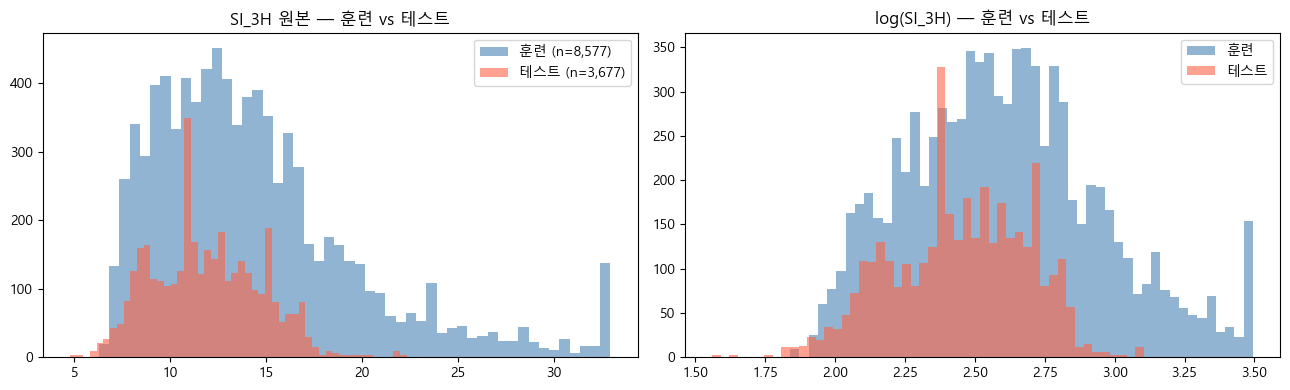

In [13]:
# ── 분포 이동(Distribution Shift) 확인 ──────────────────────────────────────
split = int(len(df) * 0.7)

print("=== SI_3H (원본) ===")
print(f"  훈련셋 평균: {df["SI_3H"].iloc[:split].mean():.4f}  |  표준편차: {df["SI_3H"].iloc[:split].std():.4f}")
print(f"  테스트셋 평균: {df["SI_3H"].iloc[split:].mean():.4f}  |  표준편차: {df["SI_3H"].iloc[split:].std():.4f}")
print(f"  평균 차이: {abs(df["SI_3H"].iloc[:split].mean() - df["SI_3H"].iloc[split:].mean()):.4f}")

print("=== log(SI_3H) ===")
print(f"  훈련셋 평균: {df["log_SI"].iloc[:split].mean():.4f}  |  표준편차: {df["log_SI"].iloc[:split].std():.4f}")
print(f"  테스트셋 평균: {df["log_SI"].iloc[split:].mean():.4f}  |  표준편차: {df["log_SI"].iloc[split:].std():.4f}")
print(f"  평균 차이: {abs(df["log_SI"].iloc[:split].mean() - df["log_SI"].iloc[split:].mean()):.4f}")

print("=== 자기상관 (Autocorrelation) — lag 피처 필요성 판단 ===")
for lag in [1, 2, 3, 9]:
    corr = df["log_SI"].autocorr(lag=lag)
    print(f"  lag={lag} (={lag*20}분): {corr:.4f}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["SI_3H"].iloc[:split], bins=50, alpha=0.6, color="steelblue", label=f"훈련 (n={split:,})")
axes[0].hist(df["SI_3H"].iloc[split:], bins=50, alpha=0.6, color="tomato", label=f"테스트 (n={len(df)-split:,})")
axes[0].set_title("SI_3H 원본 — 훈련 vs 테스트"); axes[0].legend()

axes[1].hist(df["log_SI"].iloc[:split], bins=50, alpha=0.6, color="steelblue", label="훈련")
axes[1].hist(df["log_SI"].iloc[split:], bins=50, alpha=0.6, color="tomato", label="테스트")
axes[1].set_title("log(SI_3H) — 훈련 vs 테스트"); axes[1].legend()

plt.tight_layout(); plt.show()


In [14]:
# ── Step 10-2. VIF 기반 실험 B 피처 확정 ───────────────────────────────────
PROTECTED_B = set(PROTECTED_RSM)
remaining   = list(VAR_LABELS)

def calc_vif(df_in):
    X_c  = sm.add_constant(df_in)
    cols = df_in.columns.tolist()
    vifs = [variance_inflation_factor(X_c.values, i+1) for i in range(len(cols))]
    return pd.DataFrame({"변수": cols, "피처명": [VAR_NAMES.get(c,c) for c in cols],
                         "VIF": vifs}).sort_values("VIF", ascending=False).reset_index(drop=True)

print("── 1차 VIF ──────────────────────────────────────────────")
print(calc_vif(df_rsm[remaining])[["피처명","VIF"]].to_string(index=False))

print("\n── 순차 제거 (비보호 VIF > 10) ─────────────────────────")
removed = []
while True:
    vif_df     = calc_vif(df_rsm[remaining])
    candidates = vif_df[(vif_df["VIF"] > 10) & (~vif_df["변수"].isin(PROTECTED_B))]
    if candidates.empty:
        print("  ✓ 비보호 변수 중 VIF > 10 없음 — 종료"); break
    tgt = candidates.iloc[0]["변수"]
    print(f"  제거: {VAR_NAMES.get(tgt,tgt):<35s}  VIF = {candidates.iloc[0]['VIF']:.2f}")
    remaining.remove(tgt); removed.append(tgt)

print(f"\n최종 유지 변수 ({len(remaining)}개):")
for v in remaining:
    print(f"  {VAR_NAMES.get(v,v)}")

print("\n── 최종 VIF ─────────────────────────────────────────────")
print(calc_vif(df_rsm[remaining])[["피처명","VIF"]].to_string(index=False))

X_B       = pd.concat([df_rsm[remaining], df[LAG_COLS]], axis=1)
X_B_train = X_B.iloc[:split]
X_B_test  = X_B.iloc[split:]
print(f"\nfeat_B 확정 ({len(remaining)}개): {[VAR_NAMES.get(f,f) for f in remaining]}")

── 1차 VIF ──────────────────────────────────────────────
                     피처명       VIF
             % Iron Feed 18.889288
           % Silica Feed 18.710621
  Rougher Air (Col01~03)  2.356316
  Cleaner Air (Col04~07)  2.319895
              Amina Flow  2.229841
        Ore Pulp Density  2.013339
Rougher Level (Col01~03)  1.872359
             Starch Flow  1.494574
Cleaner Level (Col04~07)  1.434926
           Ore Pulp Flow  1.258762
             Ore Pulp pH  1.170520

── 순차 제거 (비보호 VIF > 10) ─────────────────────────
  ✓ 비보호 변수 중 VIF > 10 없음 — 종료

최종 유지 변수 (11개):
  % Iron Feed
  % Silica Feed
  Starch Flow
  Amina Flow
  Ore Pulp Flow
  Ore Pulp pH
  Ore Pulp Density
  Rougher Air (Col01~03)
  Cleaner Air (Col04~07)
  Rougher Level (Col01~03)
  Cleaner Level (Col04~07)

── 최종 VIF ─────────────────────────────────────────────
                     피처명       VIF
             % Iron Feed 18.889288
           % Silica Feed 18.710621
  Rougher Air (Col01~03)  2.356316
  Cleaner Air (Col

In [15]:
# ── Step 10-3. XGBoost 학습 ─────────────────────────────────────────────────
XGB_PARAMS = dict(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
K = 10

def run_xgb(X_tr, X_te, label):
    fold_size = len(X_tr) // K
    cv_rmses  = []
    for k in range(K):
        v0 = k * fold_size
        v1 = (k+1)*fold_size if k < K-1 else len(X_tr)
        vi = list(range(v0, v1))
        ti = list(range(0, v0)) + list(range(v1, len(X_tr)))
        m  = xgb.XGBRegressor(**XGB_PARAMS, verbosity=0)
        m.fit(X_tr.iloc[ti], y_train.iloc[ti])
        cv_rmses.append(np.sqrt(mean_squared_error(y_train.iloc[vi], m.predict(X_tr.iloc[vi]))))
    model = xgb.XGBRegressor(**XGB_PARAMS, verbosity=0)
    model.fit(X_tr, y_train)
    pred      = model.predict(X_te)
    test_rmse = np.sqrt(mean_squared_error(y_test, pred))
    test_r2   = r2_score(y_test, pred)
    res = {'model': model, 'pred': pred, 'cv_rmse': np.mean(cv_rmses),
           'test_rmse': test_rmse, 'test_r2': test_r2}
    print(f'[{label}]')
    print(f'  CV RMSE  : {np.mean(cv_rmses):.4f} ± {np.std(cv_rmses):.4f}')
    print(f'  Test RMSE: {test_rmse:.4f}')
    print(f'  Test R²  : {test_r2:.4f}')
    return res

print("XGBoost 학습 시작...")
res_A = run_xgb(X_A_train, X_A_test, f"실험 A — 공정 {len(X_COLS)}개 + lag {len(LAG_COLS)}개")
res_B = run_xgb(X_B_train, X_B_test, f"실험 B — RSM {len(remaining)}개 + lag {len(LAG_COLS)}개")
model_A, model_B = res_A['model'], res_B['model']

XGBoost 학습 시작...
[실험 A — 공정 21개 + lag 2개]
  CV RMSE  : 0.2323 ± 0.0292
  Test RMSE: 0.2429
  Test R²  : -0.0033
[실험 B — RSM 11개 + lag 2개]
  CV RMSE  : 0.2328 ± 0.0301
  Test RMSE: 0.2408
  Test R²  : 0.0142


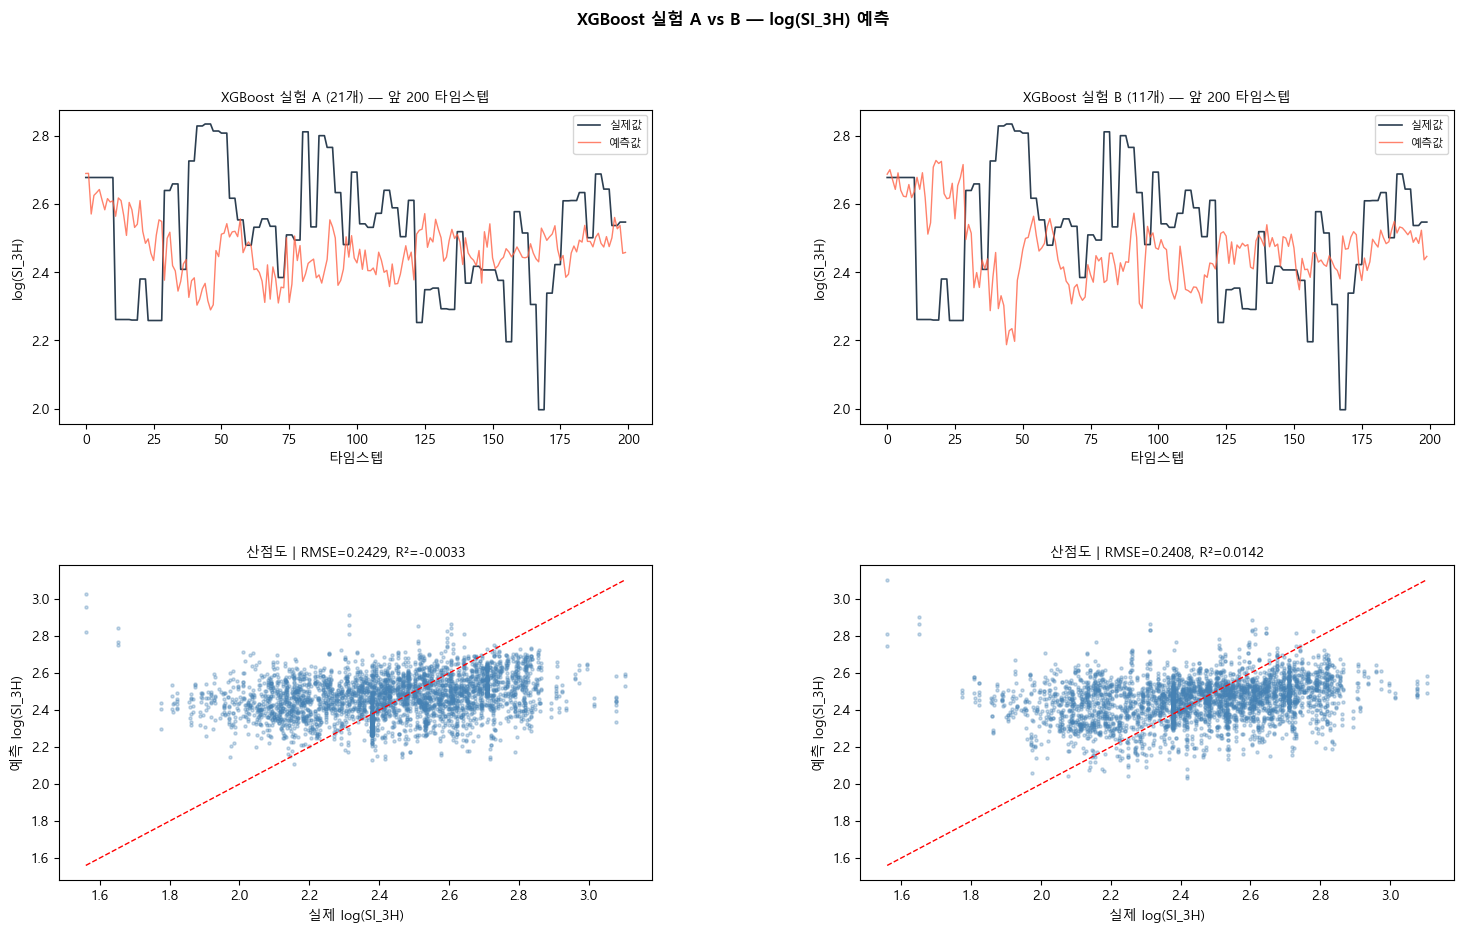

저장: xgb_SI_comparison.png

  XGBoost A vs B 최종 비교 — log(SI_3H)
  모델                          Test RMSE     Test R²
  -------------------------------------------------
  XGBoost-A (21개)                0.2429     -0.0033
  XGBoost-B (11개)                0.2408      0.0142


In [16]:
# ── Step 10-4. 결과 시각화 + 비교표 ────────────────────────────────────────
pred_A = res_A['pred']
pred_B = res_B['pred']
y_arr  = y_test.values

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

for idx, (pred, label, res) in enumerate([
    (pred_A, "실험 A (21개)", res_A),
    (pred_B, f"실험 B ({len(remaining)}개)", res_B),
]):
    ax1 = fig.add_subplot(gs[0, idx])
    ax1.plot(y_arr[:200],  color='#2c3e50', lw=1.2, label='실제값')
    ax1.plot(pred[:200],   color='tomato',  lw=1.0, alpha=0.8, label='예측값')
    ax1.set_title(f'XGBoost {label} — 앞 200 타임스텝', fontsize=10)
    ax1.set_xlabel('타임스텝'); ax1.set_ylabel('log(SI_3H)')
    ax1.legend(fontsize=8)
    ax2 = fig.add_subplot(gs[1, idx])
    ax2.scatter(y_arr, pred, alpha=0.3, s=5, color='steelblue')
    lim = [min(y_arr.min(), pred.min()), max(y_arr.max(), pred.max())]
    ax2.plot(lim, lim, 'r--', lw=1)
    ax2.set_title(f'산점도 | RMSE={res["test_rmse"]:.4f}, R²={res["test_r2"]:.4f}', fontsize=10)
    ax2.set_xlabel('실제 log(SI_3H)'); ax2.set_ylabel('예측 log(SI_3H)')

plt.suptitle('XGBoost 실험 A vs B — log(SI_3H) 예측', fontsize=12, fontweight='bold')
plt.savefig('xgb_SI_comparison.png', bbox_inches='tight')
plt.show()
print('저장: xgb_SI_comparison.png')

print('\n' + '='*55)
print('  XGBoost A vs B 최종 비교 — log(SI_3H)')
print('='*55)
print(f'  {"모델":<25s}  {"Test RMSE":>10s}  {"Test R²":>10s}')
print(f'  {"-"*49}')
for name, res in [('XGBoost-A (21개)', res_A), (f'XGBoost-B ({len(remaining)}개)', res_B)]:
    print(f'  {name:<25s}  {res["test_rmse"]:>10.4f}  {res["test_r2"]:>10.4f}')
print('='*55)